# KAMP 데이터분석

이 프로젝트의 유일한 메인 노트북은 **바탕화면/KAMP 데이터분석/kamp.ipynb**입니다.
새 분석은 이 파일 맨 아래에 셀을 추가합니다. 원본은 `data/`, PNG·CSV는 `results/`에 저장합니다.

1. 전체 weld force/current/Voltage/time 히스토그램과 원본 점검
2. 임시 force 범위 2.0~2.6, 날짜별 구성, 범위 밖 분포, 300개 반복 비교
3. 날짜별 force 범위 밖 비율·사용자 지정 불량률·Pearson 상관계수

기존 파일은 삭제하지 않고 백업했습니다. 기존 중복 노트북의 동일 셀은 한 번만 통합했습니다.
초기 분석에서 불량률 계산을 보류한 기록은 보존하며, 3부에서 사용자가 지정한 식으로 계산합니다.


In [1]:
from pathlib import Path
import os
BASE = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'kamp.ipynb').exists() and (p/'data/Welding Data Set_01.xlsx').exists())
DATA = BASE/'data'
RESULTS = BASE/'results'
RESULTS.mkdir(exist_ok=True)
os.environ['MPLCONFIGDIR'] = str(BASE/'.cache/matplotlib')
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
print('메인 노트북:', BASE/'kamp.ipynb')
print('원본 데이터:', DATA)
print('결과 저장:', RESULTS)


메인 노트북: C:\Users\sj789\OneDrive\바탕 화면\KAMP 데이터분석\kamp.ipynb
원본 데이터: C:\Users\sj789\OneDrive\바탕 화면\KAMP 데이터분석\data
결과 저장: C:\Users\sj789\OneDrive\바탕 화면\KAMP 데이터분석\results


## 1부 · 전체 측정값 히스토그램과 초기 데이터 점검
기존 EXP001의 분석 함수를 이 노트북 안에 포함했습니다.

In [2]:
"""Read-only source inspection; no target labels or row joins are inferred."""
import hashlib
import json
from pathlib import Path
import sys
import os

_CACHE = BASE / ".cache/matplotlib"
_CACHE.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(_CACHE))

import matplotlib
# Notebook inline backend retained
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = BASE
RAW = DATA
OUT = RESULTS
FEATURES = ['weld force(bar)', 'weld current(kA)', 'weld Voltage(v)', 'weld time(ms)']

def load_data():
    book = pd.read_excel(RAW / 'Welding Data Set_01.xlsx', sheet_name=None)
    scaled = pd.read_csv(RAW / 'scaled_data.csv', encoding='cp949')
    return book, scaled

def run():
    OUT.mkdir(parents=True, exist_ok=True)
    book, scaled = load_data()
    raw = book['Raw data']
    result = book['result']
    utf8 = pd.read_csv(DATA / 'scaled_data_utf8.csv', encoding='utf-8-sig')
    pd.testing.assert_frame_equal(scaled, utf8)
    report = {'python': sys.version, 'files': {}, 'sheets': {}, 'scaled': {}}
    for name in ('Welding Data Set_01.xlsx', 'scaled_data.csv'):
        report['files'][name] = hashlib.sha256((RAW / name).read_bytes()).hexdigest()
    for name, frame in book.items():
        report['sheets'][name] = {
            'rows': len(frame), 'columns': list(frame.columns),
            'missing': frame.isna().sum().to_dict(),
            'duplicate_rows': int(frame.duplicated().sum()),
            'dtypes': frame.dtypes.astype(str).to_dict(),
        }
    report['raw'] = {
        'idx_unique': bool(raw['idx'].is_unique),
        'time_min': str(raw['working time'].min()), 'time_max': str(raw['working time'].max()),
        'machines': int(raw['Machine_Name'].nunique()), 'items': int(raw['Item No'].nunique()),
    }
    report['scaled'] = {
        'rows': len(scaled), 'columns': list(scaled.columns), 'encoding': 'cp949',
        'utf8_roundtrip_equal': True,
        'index_is_zero_based_sequence': bool(np.array_equal(scaled.iloc[:, 0], np.arange(len(scaled)))),
        'missing': scaled.isna().sum().to_dict(),
    }
    # Compare by supplied row order only. Numerical agreement is not proof of provenance.
    comparison = {}
    if len(raw) == len(scaled):
        for original, transformed in zip(FEATURES, scaled.columns[1:]):
            x = raw[original]
            expected = (x - x.min()) / (x.max() - x.min())
            comparison[original] = {
                'scaled_column': transformed,
                'max_abs_error_vs_full_data_minmax': float((expected - scaled[transformed]).abs().max()),
                'matches_at_1e-8': bool(np.allclose(expected, scaled[transformed], atol=1e-8, rtol=0)),
            }
    report['row_order_minmax_comparison'] = comparison
    report['result'] = {
        'rows': len(result), 'defect_values': sorted(result['defect'].unique().tolist()),
        'defect_type_values': sorted(result['defect type'].unique().tolist()),
        'unique_dates': int(result['working time'].nunique()),
        'label_join': 'NOT PERFORMED: observation unit and target definition unconfirmed',
    }
    raw.describe(include='all').to_csv(OUT / 'raw_summary.csv', encoding='utf-8-sig')
    raw.isna().sum().rename('missing').to_csv(OUT / 'missing.csv', encoding='utf-8-sig')
    raw.groupby(raw['working time'].dt.date).size().rename('rows').to_csv(OUT / 'daily_counts.csv', encoding='utf-8-sig')
    raw[FEATURES].hist(bins=50, figsize=(12, 7))
    plt.tight_layout()
    plt.savefig(OUT / 'distributions.png', dpi=140)
    plt.close('all')
    (OUT / 'inspection.json').write_text(json.dumps(report, ensure_ascii=False, indent=2), encoding='utf-8')
    print(json.dumps(report, ensure_ascii=True, indent=2))
    return report



# YSJ · EXP001 데이터 점검
계획과 결과 문서를 함께 확인하세요. 원본은 변경하지 않습니다. result를 행별 정답으로 결합하지 않습니다.

In [3]:
print('Python:', sys.executable)
book, scaled = load_data()

Python: C:\Users\sj789\Documents\Codex\2026-09-23\https-github-com-kamp-blacktea2-kamp\Kamp-2026\.venv\Scripts\python.exe


In [4]:
for name, frame in book.items():
    print(name, frame.shape)
    display(frame.head())
print("CSV: CP949")
display(scaled.head())

Raw data (11939, 10)


,idx,Machine_Name,Item No,working time,Thickness 1(mm),Thickness 2(mm),weld force(bar),weld current(kA),weld Voltage(v),weld time(ms)
0,1,Spot-01,65235-25800,2020-03-24,0.7,0.7,2.33,14.57,2.701,72.0
1,2,Spot-01,65235-25800,2020-03-24,0.7,0.7,2.36,14.57,2.701,72.0
2,3,Spot-01,65235-25800,2020-03-24,0.7,0.7,2.37,14.54,2.703,71.0
3,4,Spot-01,65235-25800,2020-03-24,0.7,0.7,2.37,14.54,2.703,72.0
4,5,Spot-01,65235-25800,2020-03-24,0.7,0.7,2.36,14.56,2.704,72.0


result (23, 7)


,idx,Machine_Name,Item No,working time,defect,defect type,Unnamed: 6
0,1,Spot-01,65235-25800,2020-03-24,2,1,파임불량
1,2,Spot-01,65235-25800,2020-03-24,1,2,용접부족
2,3,Spot-01,65235-25800,2020-03-24,1,3,크랙발생
3,4,Spot-01,65235-25800,2020-03-25,3,1,NaN
4,5,Spot-01,65235-25800,2020-03-25,2,2,NaN


data set (10, 3)


,Data,항목 설명,수집 범위
0,idx,생산순번,-
1,Machine_Name,생산설비,-
2,Item No,생산품목,-
3,working time,작업시간,-
4,Thickness 1(mm),소재 두께 1,0.3-2.3


CSV: CP949


,Unnamed: 0,용접 가압력,전류,전압,통전시간
0,0,0.004482,0.001717,0.002506,0.000461
1,1,0.005412,0.000501,0.002506,0.000922
2,2,0.004989,0.000358,0.507830,0.000922
3,3,0.005243,0.000358,0.002506,0.000922
4,4,0.005327,0.000143,0.002506,0.000461


In [5]:
raw = book["Raw data"]
display(raw.describe(include="all"))
display(scaled.isna().sum().to_frame("missing"))

,idx,Machine_Name,Item No,working time,Thickness 1(mm),Thickness 2(mm),weld force(bar),weld current(kA),weld Voltage(v),weld time(ms)
count,11939.000000,11939,11939,11939,1.193900e+04,1.193900e+04,11939.000000,11939.000000,11939.000000,11939.000000
unique,NaN,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Spot-01,65235-25800,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,11939,11939,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,732.280761,NaN,NaN,2020-03-29 10:49:44.571572,7.000000e-01,7.000000e-01,2.787925,14.711208,2.704223,71.724123
min,1.000000,NaN,NaN,2020-03-24 00:00:00,7.000000e-01,7.000000e-01,1.740000,14.520000,2.464000,70.000000
25%,332.000000,NaN,NaN,2020-03-26 00:00:00,7.000000e-01,7.000000e-01,2.310000,14.610000,2.699000,71.000000
50%,664.000000,NaN,NaN,2020-03-30 00:00:00,7.000000e-01,7.000000e-01,2.340000,14.730000,2.702000,72.000000
75%,1081.000000,NaN,NaN,2020-04-02 00:00:00,7.000000e-01,7.000000e-01,2.370000,14.750000,2.706000,72.000000
max,2000.000000,NaN,NaN,2020-04-07 00:00:00,7.000000e-01,7.000000e-01,10.540000,15.070000,2.861000,73.000000


,missing
Unnamed: 0,0
용접 가압력,18
전류,15
전압,15
통전시간,23


{
  "python": "3.12.14 (main, Aug 25 2026, 14:01:42) [MSC v.1944 64 bit (AMD64)]",
  "files": {
    "Welding Data Set_01.xlsx": "d514d6aaa121630c04d7d51c97a56025e78e2c86868813f7722ba5db922c1f33",
    "scaled_data.csv": "a267d1eaab5ca7c81205e38dbb7fb024ebbcb25b866d8cc0907890526e4edfb6"
  },
  "sheets": {
    "Raw data": {
      "rows": 11939,
      "columns": [
        "idx",
        "Machine_Name",
        "Item No",
        "working time",
        "Thickness 1(mm)",
        "Thickness 2(mm)",
        "weld force(bar)",
        "weld current(kA)",
        "weld Voltage(v)",
        "weld time(ms)"
      ],
      "missing": {
        "idx": 0,
        "Machine_Name": 0,
        "Item No": 0,
        "working time": 0,
        "Thickness 1(mm)": 0,
        "Thickness 2(mm)": 0,
        "weld force(bar)": 0,
        "weld current(kA)": 0,
        "weld Voltage(v)": 0,
        "weld time(ms)": 0
      },
      "duplicate_rows": 0,
      "dtypes": {
        "idx": "int64",
        "Machine_

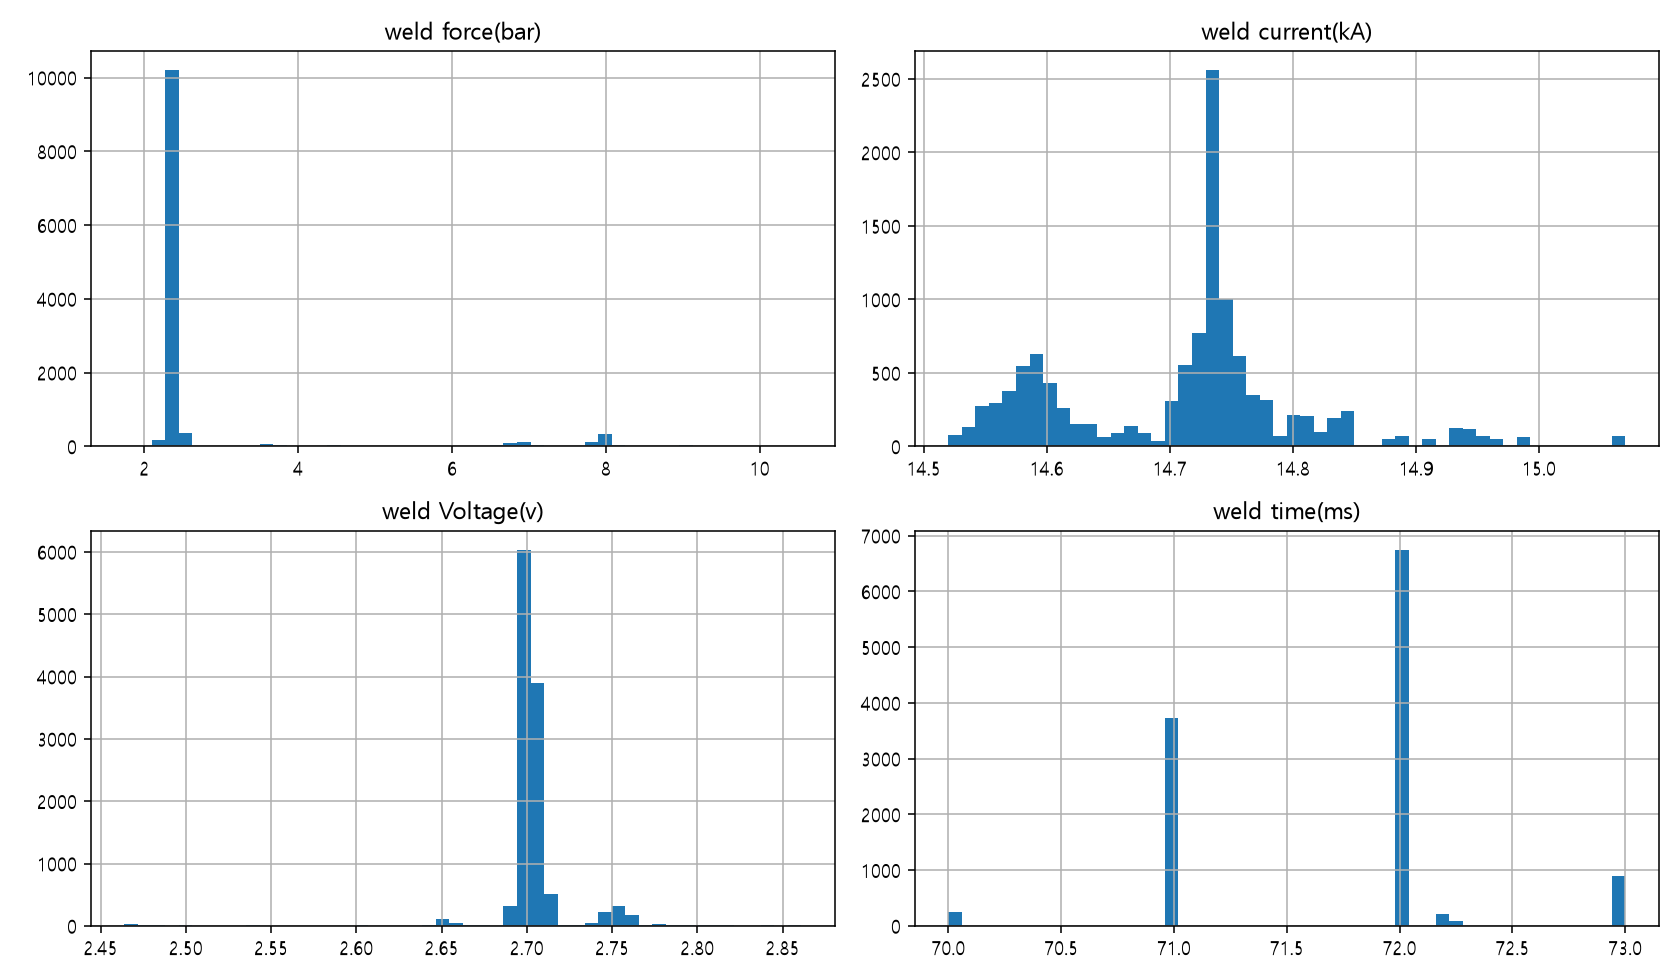

In [6]:
report = run()
from IPython.display import Image, display
display(Image(filename=str(OUT / "distributions.png")))

## 다음 단계
CSV 생성 과정과 result의 관측 단위를 확인한 뒤 분석 질문을 정하세요. 학습 전에는 시간·그룹 분할과 라벨 정의를 확정하고 전처리를 학습 데이터에만 fit하세요. Git 공유 전 출력은 지우세요.

## 2부 · 임시 force 범위·날짜별 구성·300개 반복 데이터
이 절의 불량률 보류 기록은 초기 분석의 기록입니다. 지정식의 실제 계산은 3부에 이어집니다.

# EXP002 · weld force 날짜별 EDA
분석 기준 2.0~2.6 bar는 사용자가 정한 **임시 탐색 범위**입니다. 일반 그룹이라는 이름은 정상 품질 판정이 아닙니다.
원본 행을 삭제하거나 정상/불량 개별 라벨을 만들지 않습니다. 아래 셀을 위에서부터 실행합니다.

In [7]:
from pathlib import Path
from itertools import combinations
from collections import Counter
import hashlib
import json
import os
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = BASE
OUT = RESULTS
OUT.mkdir(parents=True, exist_ok=True)
os.environ.setdefault('MPLCONFIGDIR', str(BASE / '.cache/matplotlib'))
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows 한글 폰트
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_columns', 30)
BOOK = DATA / 'Welding Data Set_01.xlsx'
source_hash = hashlib.sha256(BOOK.read_bytes()).hexdigest()
FORCE = 'weld force(bar)'
FEATURES = [FORCE, 'weld current(kA)', 'weld Voltage(v)', 'weld time(ms)']
LOW, HIGH = 2.0, 2.6  # 임시 탐색 기준이며 정상/불량 또는 관리 한계가 아님
print('임시 기준:', LOW, '<= force <=', HIGH, '| 원본 SHA-256:', source_hash)

임시 기준: 2.0 <= force <= 2.6 | 원본 SHA-256: d514d6aaa121630c04d7d51c97a56025e78e2c86868813f7722ba5db922c1f33


## 1. 원본 읽기와 날짜 추출
날짜/force를 읽을 수 없는 행은 별도 표시합니다. 원본은 수정하지 않습니다.

In [8]:
raw = pd.read_excel(BOOK, sheet_name='Raw data')
result = pd.read_excel(BOOK, sheet_name='result')
raw_original = raw.copy(deep=True)
raw['원본_행위치'] = np.arange(len(raw))
raw['날짜'] = pd.to_datetime(raw['working time'], errors='coerce').dt.normalize()
result['날짜'] = pd.to_datetime(result['working time'], errors='coerce').dt.normalize()
force = pd.to_numeric(raw[FORCE], errors='coerce')
print('Raw data / result 크기:', raw.shape, result.shape)
display(raw.head())
invalid_dates = raw.loc[raw['날짜'].isna()]
invalid_force = raw.loc[force.isna()]
print('원본 날짜 해석 불가:', len(invalid_dates), '| force 결측/해석 불가:', len(invalid_force))
print('result 날짜 해석 불가:', int(result['날짜'].isna().sum()))
display(invalid_dates)
display(invalid_force)
raw['날짜'].value_counts().sort_index().rename('원본 행 수').to_frame()

Raw data / result 크기: (11939, 12) (23, 8)


,idx,Machine_Name,Item No,working time,Thickness 1(mm),Thickness 2(mm),weld force(bar),weld current(kA),weld Voltage(v),weld time(ms),원본_행위치,날짜
0,1,Spot-01,65235-25800,2020-03-24,0.7,0.7,2.33,14.57,2.701,72.0,0,2020-03-24
1,2,Spot-01,65235-25800,2020-03-24,0.7,0.7,2.36,14.57,2.701,72.0,1,2020-03-24
2,3,Spot-01,65235-25800,2020-03-24,0.7,0.7,2.37,14.54,2.703,71.0,2,2020-03-24
3,4,Spot-01,65235-25800,2020-03-24,0.7,0.7,2.37,14.54,2.703,72.0,3,2020-03-24
4,5,Spot-01,65235-25800,2020-03-24,0.7,0.7,2.36,14.56,2.704,72.0,4,2020-03-24


원본 날짜 해석 불가: 0 | force 결측/해석 불가: 0
result 날짜 해석 불가: 0


,idx,Machine_Name,Item No,working time,Thickness 1(mm),Thickness 2(mm),weld force(bar),weld current(kA),weld Voltage(v),weld time(ms),원본_행위치,날짜


,idx,Machine_Name,Item No,working time,Thickness 1(mm),Thickness 2(mm),weld force(bar),weld current(kA),weld Voltage(v),weld time(ms),원본_행위치,날짜


,원본 행 수
날짜,
2020-03-24,1200
2020-03-25,1352
2020-03-26,1000
2020-03-27,1648
2020-03-30,1470
2020-03-31,1800
2020-04-02,2000
2020-04-03,800
2020-04-07,669


## 2. 임시 force 그룹
양 끝값 2.0과 2.6을 포함합니다. 결측은 범위 밖으로 잘못 분류하지 않습니다.

In [9]:
inside_mask = force.between(LOW, HIGH, inclusive='both') & force.notna()
outside_mask = force.notna() & ~inside_mask
raw['force_그룹'] = np.select([inside_mask, outside_mask], ['일반 force 그룹(임시)', '범위 밖 force 그룹(임시)'], default='force 미확인')
print('그룹은 공정 정상/불량 라벨이 아닙니다.')
display(raw['force_그룹'].value_counts().rename('개수').to_frame())
assert int(inside_mask.sum() + outside_mask.sum() + force.isna().sum()) == len(raw)

그룹은 공정 정상/불량 라벨이 아닙니다.


,개수
force_그룹,
일반 force 그룹(임시),10739
범위 밖 force 그룹(임시),1200


## 3. 날짜별 개수와 비율
비율의 분모는 해당 날짜의 전체 원본 행 수입니다. 날짜 미확인 행은 앞 단계에서 별도 표시했습니다.

In [10]:
raw['범위_내'] = inside_mask
raw['범위_밖'] = outside_mask
raw['force_미확인'] = force.isna()
daily = raw.groupby('날짜', dropna=False).agg(
    전체_데이터_개수=(FORCE, 'size'),
    범위_내_개수=('범위_내', 'sum'),
    범위_밖_개수=('범위_밖', 'sum'),
    force_미확인_개수=('force_미확인', 'sum'),
).reset_index()
daily['범위_내_비율(%)'] = daily['범위_내_개수'] / daily['전체_데이터_개수'] * 100
daily['범위_밖_비율(%)'] = daily['범위_밖_개수'] / daily['전체_데이터_개수'] * 100
daily = daily[['날짜', '전체_데이터_개수', '범위_내_개수', '범위_내_비율(%)', '범위_밖_개수', '범위_밖_비율(%)', 'force_미확인_개수']]
print('범위 내 = 2.0~2.6 bar (임시 기준)')
display(daily.round(3))
assert daily['전체_데이터_개수'].sum() == len(raw)
assert (daily['전체_데이터_개수'] == daily['범위_내_개수'] + daily['범위_밖_개수'] + daily['force_미확인_개수']).all()
daily.to_csv(OUT / 'daily_force.csv', index=False, encoding='utf-8-sig')

범위 내 = 2.0~2.6 bar (임시 기준)


C:\Users\sj789\AppData\Local\Temp\ipykernel_25144\4115128808.py:14: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(daily.round(3))


,날짜,전체_데이터_개수,범위_내_개수,범위_내_비율(%),범위_밖_개수,범위_밖_비율(%),force_미확인_개수
0,2020-03-24,1200,1200,100.000,0,0.000,0
1,2020-03-25,1352,1052,77.811,300,22.189,0
2,2020-03-26,1000,1000,100.000,0,0.000,0
3,2020-03-27,1648,1348,81.796,300,18.204,0
4,2020-03-30,1470,1470,100.000,0,0.000,0
5,2020-03-31,1800,1500,83.333,300,16.667,0
6,2020-04-02,2000,2000,100.000,0,0.000,0
7,2020-04-03,800,500,62.500,300,37.500,0
8,2020-04-07,669,669,100.000,0,0.000,0


## 4. result의 날짜 대응과 불량 정보
날짜를 정확하게 대응시킵니다. result의 defect가 중복 없는 불량 제품 수인지, Raw data의 한 행이 제품 하나인지 문서상 확인되지 않았습니다.
따라서 **defect 수치 합계는 참고값으로만 표시**하고 실제 불량 개수·생산량·불량률은 미확정으로 둡니다. 원본 행 수를 생산량으로 단정하거나 누락을 0건으로 바꾸지 않습니다.

In [11]:
print('result 원본:')
display(result)
keys = ['Machine_Name', 'Item No']
raw_entities = raw.groupby('날짜')[keys].apply(lambda x: set(map(tuple, x.to_numpy())))
result_entities = result.groupby('날짜')[keys].apply(lambda x: set(map(tuple, x.to_numpy())))
result_daily = result.dropna(subset=['날짜']).groupby('날짜').agg(
    result_행수=('defect', 'size'),
    defect_수치합계_참고=('defect', lambda x: x.sum(min_count=1)),
    기록된_불량유형=('defect type', lambda x: ', '.join(map(str, sorted(x.dropna().unique())))),
).reset_index()
quality = daily.merge(result_daily, on='날짜', how='outer', validate='one_to_one', indicator=True)
quality['날짜_매칭상태'] = quality['_merge'].map({'both':'날짜 일치', 'left_only':'result 날짜 없음', 'right_only':'Raw data 날짜 없음'}).astype(str)
quality['설비_품목_집합일치'] = quality['날짜'].map(lambda d: raw_entities.get(d) == result_entities.get(d) if d in raw_entities.index and d in result_entities.index else pd.NA)
quality['불량_개수'] = pd.Series(pd.NA, index=quality.index, dtype='Int64')
quality['생산량'] = pd.Series(pd.NA, index=quality.index, dtype='Int64')
quality['불량률(%)'] = pd.Series(pd.NA, index=quality.index, dtype='Float64')
quality['품질_집계상태'] = '불량 개수/생산량 정의 미확정: 불량률 계산 보류'
quality = quality.drop(columns='_merge').sort_values('날짜')
display(quality.round(3))
print('날짜가 일치하지 않는 행:')
display(quality.loc[quality['날짜_매칭상태'] != '날짜 일치'])
print('날짜 해석 불가 result 행:')
display(result.loc[result['날짜'].isna()])
quality.to_csv(OUT / 'daily_force_result.csv', index=False, encoding='utf-8-sig')

result 원본:


,idx,Machine_Name,Item No,working time,defect,defect type,Unnamed: 6,날짜
0,1,Spot-01,65235-25800,2020-03-24,2,1,파임불량,2020-03-24
1,2,Spot-01,65235-25800,2020-03-24,1,2,용접부족,2020-03-24
2,3,Spot-01,65235-25800,2020-03-24,1,3,크랙발생,2020-03-24
3,4,Spot-01,65235-25800,2020-03-25,3,1,NaN,2020-03-25
4,5,Spot-01,65235-25800,2020-03-25,2,2,NaN,2020-03-25
5,6,Spot-01,65235-25800,2020-03-25,3,3,NaN,2020-03-25
6,7,Spot-01,65235-25800,2020-03-26,3,1,NaN,2020-03-26
7,8,Spot-01,65235-25800,2020-03-26,2,2,NaN,2020-03-26
8,9,Spot-01,65235-25800,2020-03-26,2,3,NaN,2020-03-26
9,10,Spot-01,65235-25800,2020-03-30,1,1,NaN,2020-03-30


C:\Users\sj789\AppData\Local\Temp\ipykernel_25144\4186492697.py:19: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(quality.round(3))


,날짜,전체_데이터_개수,범위_내_개수,범위_내_비율(%),범위_밖_개수,범위_밖_비율(%),force_미확인_개수,result_행수,defect_수치합계_참고,기록된_불량유형,날짜_매칭상태,설비_품목_집합일치,불량_개수,생산량,불량률(%),품질_집계상태
0,2020-03-24,1200,1200,100.000,0,0.000,0,3.0,4.0,"1, 2, 3",날짜 일치,True,<NA>,<NA>,<NA>,불량 개수/생산량 정의 미확정: 불량률 계산 보류
1,2020-03-25,1352,1052,77.811,300,22.189,0,3.0,8.0,"1, 2, 3",날짜 일치,True,<NA>,<NA>,<NA>,불량 개수/생산량 정의 미확정: 불량률 계산 보류
2,2020-03-26,1000,1000,100.000,0,0.000,0,3.0,7.0,"1, 2, 3",날짜 일치,True,<NA>,<NA>,<NA>,불량 개수/생산량 정의 미확정: 불량률 계산 보류
3,2020-03-27,1648,1348,81.796,300,18.204,0,NaN,NaN,NaN,result 날짜 없음,<NA>,<NA>,<NA>,<NA>,불량 개수/생산량 정의 미확정: 불량률 계산 보류
4,2020-03-30,1470,1470,100.000,0,0.000,0,3.0,4.0,"1, 2, 3",날짜 일치,True,<NA>,<NA>,<NA>,불량 개수/생산량 정의 미확정: 불량률 계산 보류
5,2020-03-31,1800,1500,83.333,300,16.667,0,2.0,5.0,"1, 2",날짜 일치,True,<NA>,<NA>,<NA>,불량 개수/생산량 정의 미확정: 불량률 계산 보류
6,2020-04-02,2000,2000,100.000,0,0.000,0,3.0,4.0,"1, 2, 3",날짜 일치,True,<NA>,<NA>,<NA>,불량 개수/생산량 정의 미확정: 불량률 계산 보류
7,2020-04-03,800,500,62.500,300,37.500,0,3.0,4.0,"1, 2, 3",날짜 일치,True,<NA>,<NA>,<NA>,불량 개수/생산량 정의 미확정: 불량률 계산 보류
8,2020-04-07,669,669,100.000,0,0.000,0,3.0,3.0,"1, 2, 3",날짜 일치,True,<NA>,<NA>,<NA>,불량 개수/생산량 정의 미확정: 불량률 계산 보류


날짜가 일치하지 않는 행:


,날짜,전체_데이터_개수,범위_내_개수,범위_내_비율(%),범위_밖_개수,범위_밖_비율(%),force_미확인_개수,result_행수,defect_수치합계_참고,기록된_불량유형,날짜_매칭상태,설비_품목_집합일치,불량_개수,생산량,불량률(%),품질_집계상태
3,2020-03-27,1648,1348,81.796117,300,18.203883,0,NaN,NaN,NaN,result 날짜 없음,<NA>,<NA>,<NA>,<NA>,불량 개수/생산량 정의 미확정: 불량률 계산 보류


날짜 해석 불가 result 행:


,idx,Machine_Name,Item No,working time,defect,defect type,Unnamed: 6,날짜


## 5. 날짜별 두 그룹의 비율
누적 막대의 두 색은 임시 force 범위를 나타내며 정상·불량 비율이 아닙니다.

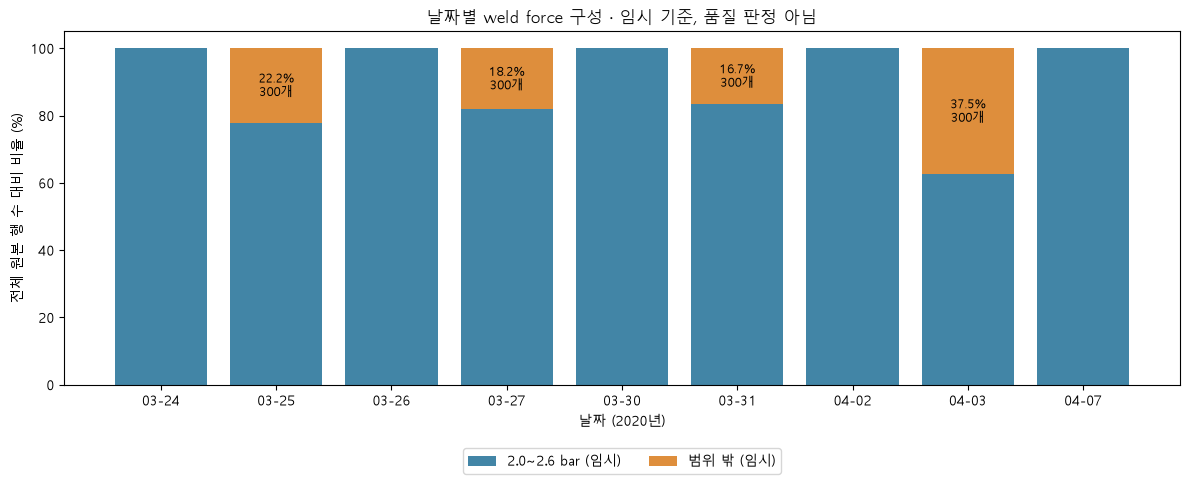

In [12]:
plot_daily = daily.dropna(subset=['날짜']).set_index('날짜')
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(plot_daily))
a = plot_daily['범위_내_비율(%)']
b = plot_daily['범위_밖_비율(%)']
ax.bar(x, a, color='#4285A6', label='2.0~2.6 bar (임시)')
ax.bar(x, b, bottom=a, color='#DE8E3C', label='범위 밖 (임시)')
for i, (_, row) in enumerate(plot_daily.iterrows()):
    if row['범위_밖_개수']:
        ax.text(i, 100 - row['범위_밖_비율(%)']/2, f"{row['범위_밖_비율(%)']:.1f}%\n{int(row['범위_밖_개수'])}개", ha='center', va='center', fontsize=9)
ax.set_xticks(x, plot_daily.index.strftime('%m-%d'))
ax.set_ylim(0, 105)
ax.set_xlabel('날짜 (2020년)')
ax.set_ylabel('전체 원본 행 수 대비 비율 (%)')
ax.set_title('날짜별 weld force 구성 · 임시 기준, 품질 판정 아님')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.16), ncol=2)
fig.tight_layout()
fig.savefig(OUT / 'daily_force_ratio.png', dpi=160, bbox_inches='tight')
plt.show()
plt.close(fig)

## 6. 범위 밖 force만 추출하고 분포 확인
0.2 bar 고정 폭 구간과 정확한 값별 빈도를 함께 확인합니다. 반올림 없이 추출하며 원본을 삭제하지 않습니다.

범위 밖 행 수: 1200


,idx,Machine_Name,Item No,working time,Thickness 1(mm),Thickness 2(mm),weld force(bar),weld current(kA),weld Voltage(v),weld time(ms),원본_행위치,날짜,force_그룹,범위_내,범위_밖,force_미확인
1749,550,Spot-01,65235-25800,2020-03-25,0.7,0.7,1.74,14.72,2.702,71.0,1749,2020-03-25,범위 밖 force 그룹(임시),False,True,False
1750,551,Spot-01,65235-25800,2020-03-25,0.7,0.7,1.74,14.71,2.702,72.0,1750,2020-03-25,범위 밖 force 그룹(임시),False,True,False
1877,678,Spot-01,65235-25800,2020-03-25,0.7,0.7,10.54,14.75,2.476,72.0,1877,2020-03-25,범위 밖 force 그룹(임시),False,True,False
1878,679,Spot-01,65235-25800,2020-03-25,0.7,0.7,10.54,14.76,2.476,72.0,1878,2020-03-25,범위 밖 force 그룹(임시),False,True,False
1879,680,Spot-01,65235-25800,2020-03-25,0.7,0.7,9.27,14.76,2.474,72.0,1879,2020-03-25,범위 밖 force 그룹(임시),False,True,False


,weld force(bar),weld current(kA),weld Voltage(v),weld time(ms)
count,1200.000000,1200.000000,1200.00000,1200.000000
mean,6.819967,14.843667,2.72505,71.710000
std,1.732265,0.089584,0.07016,0.626813
min,1.740000,14.710000,2.46400,70.000000
25%,6.190000,14.780000,2.70575,71.000000
50%,7.505000,14.830000,2.75000,72.000000
75%,7.910000,14.930000,2.75700,72.000000
max,10.540000,15.070000,2.86100,73.000000


정확한 force 값별 상위 20개:


,weld force(bar),개수
0,7.90,108
1,7.91,108
2,7.89,84
3,7.92,52
4,7.93,36
5,3.64,20
6,7.88,20
17,3.65,12
18,5.14,12
10,6.70,12


0.2 bar 구간별 빈도 상위 15개 ([하한, 상한), 마지막 구간은 상한 포함):


,구간_하한,구간_상한,개수
31,7.8,8.0,432
26,6.8,7.0,132
10,3.6,3.8,80
25,6.6,6.8,80
27,7.0,7.2,48
17,5.0,5.2,36
14,4.4,4.6,36
37,9.0,9.2,36
29,7.4,7.6,24
6,2.8,3.0,24


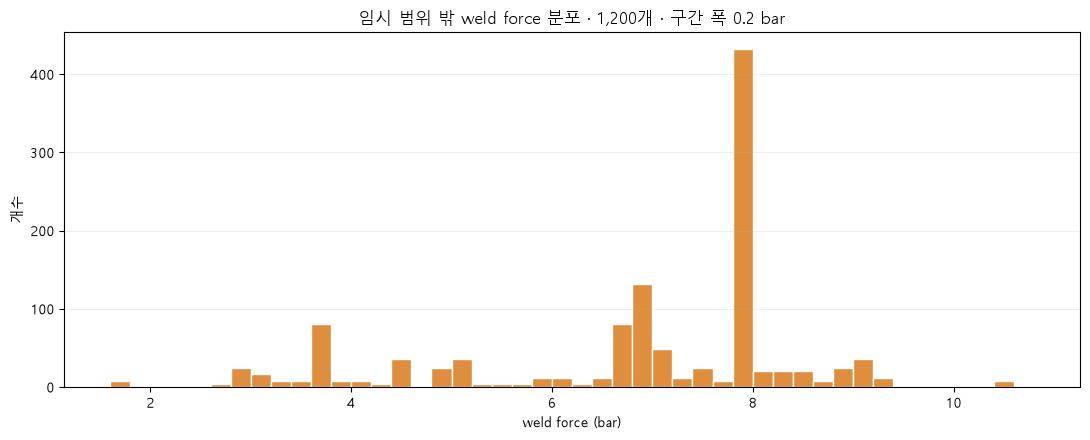

In [13]:
outside = raw.loc[outside_mask].copy()
print('범위 밖 행 수:', len(outside))
display(outside.head())
display(outside[FEATURES].describe())
value_counts = outside[FORCE].value_counts().rename_axis('weld force(bar)').reset_index(name='개수').sort_values(['개수', FORCE], ascending=[False, True])
print('정확한 force 값별 상위 20개:')
display(value_counts.head(20))
step = 0.2
edges = np.arange(np.floor(outside[FORCE].min()/step)*step, np.ceil(outside[FORCE].max()/step)*step + step*1.5, step)
counts, edges = np.histogram(outside[FORCE], bins=edges)
bin_table = pd.DataFrame({'구간_하한':edges[:-1], '구간_상한':edges[1:], '개수':counts})
print('0.2 bar 구간별 빈도 상위 15개 ([하한, 상한), 마지막 구간은 상한 포함):')
display(bin_table.sort_values('개수', ascending=False).head(15).round(4))
assert counts.sum() == len(outside)
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.hist(outside[FORCE], bins=edges, color='#DE8E3C', edgecolor='white')
ax.set(xlabel='weld force (bar)', ylabel='개수', title=f'임시 범위 밖 weld force 분포 · {len(outside):,}개 · 구간 폭 0.2 bar')
ax.grid(axis='y', alpha=.2)
fig.tight_layout()
fig.savefig(OUT / 'outside_force_hist.png', dpi=160)
plt.show()
plt.close(fig)
outside.to_csv(OUT / 'outside_force_rows.csv', index=False, encoding='utf-8-sig')
value_counts.to_csv(OUT / 'outside_exact_value_counts.csv', index=False, encoding='utf-8-sig')
bin_table.to_csv(OUT / 'outside_bin_counts.csv', index=False, encoding='utf-8-sig')

## 7. 범위 밖 force가 정확히 300개인 날짜

In [14]:
days300 = daily.loc[daily['범위_밖_개수'].eq(300), ['날짜', '전체_데이터_개수', '범위_밖_개수', '범위_밖_비율(%)']]
print('정확히 300개인 날짜 수:', len(days300))
display(days300.round(3))
days300.to_csv(OUT / 'days_with_300.csv', index=False, encoding='utf-8-sig')

정확히 300개인 날짜 수: 4


C:\Users\sj789\AppData\Local\Temp\ipykernel_25144\1352533395.py:3: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(days300.round(3))


,날짜,전체_데이터_개수,범위_밖_개수,범위_밖_비율(%)
1,2020-03-25,1352,300,22.189
3,2020-03-27,1648,300,18.204
5,2020-03-31,1800,300,16.667
7,2020-04-03,800,300,37.500


## 8. 300개 관측의 네 열을 날짜 사이에서 비교
**순서까지 동일**: 원본에서 나타난 순서대로 네 값이 모두 같음.
**행 조합·빈도 동일**: 순서를 무시하되 중복 횟수를 포함한 네 값의 조합이 모두 같음.
**주변분포 동일**: 각 열 값·빈도는 같아도 네 열의 조합은 다를 수 있음.
분포 거리는 두 경험누적분포의 최대 차이(0~1)이며 유의확률이 아닙니다. 거리 ≤0.10을 네 열 모두 만족하면 설명용으로 '분포만 유사(임시)'라 표시합니다. 이는 통계적 동등성이나 공정 정상성 판정이 아닙니다.
날짜와 생산순번은 이 네 열 동일성 판정에 포함하지 않습니다. 정확한 일치에는 반올림/허용오차를 쓰지 않습니다.

In [15]:
def ecdf_distance(a, b):
    a, b = np.sort(a), np.sort(b)
    support = np.union1d(a, b)
    return float(np.max(np.abs(np.searchsorted(a, support, side='right') / len(a) - np.searchsorted(b, support, side='right') / len(b))))

blocks = {d: outside.loc[outside['날짜'].eq(d), FEATURES].reset_index(drop=True) for d in days300['날짜']}
block_summary = []
for date, block in blocks.items():
    positions = outside.loc[outside['날짜'].eq(date), '원본_행위치'].to_numpy()
    block_summary.append({'날짜':date, '행수':len(block), '네열_고유조합수':len(block.drop_duplicates()), '중복_추가행수':int(block.duplicated().sum()), '원본행위치_연속':bool((np.diff(positions)==1).all())})
display(pd.DataFrame(block_summary))
assert all(not block.isna().any().any() for block in blocks.values()), '네 열 결측이 있어 정확 비교 방식을 재검토해야 합니다.'
pairs = []
distribution_rows = []
for day_a, day_b in combinations(blocks, 2):
    a, b = blocks[day_a], blocks[day_b]
    ca, cb = Counter(map(tuple, a.to_numpy())), Counter(map(tuple, b.to_numpy()))
    exact_order = a.equals(b)
    exact_multiset = ca == cb
    common = sum((ca & cb).values())
    distances = {col:ecdf_distance(a[col].to_numpy(), b[col].to_numpy()) for col in FEATURES}
    marginal_equal = all(Counter(a[col]) == Counter(b[col]) for col in FEATURES)
    if exact_order:
        verdict = '네 열 및 원본 순서 완전 동일'
    elif exact_multiset:
        verdict = '네 열 행 조합·빈도 동일, 순서 다름'
    elif marginal_equal:
        verdict = '열별 분포 동일, 네 열 조합 다름'
    elif max(distances.values()) <= 0.10:
        verdict = '정확 일치 아님, 분포만 유사(임시 D≤0.10)'
    else:
        verdict = '정확 일치 아님, 분포 차이 있음'
    pairs.append({'날짜_A':day_a, '날짜_B':day_b, '순서까지_동일':exact_order, '네열_조합빈도_동일':exact_multiset, '공통_행수_중복횟수포함':common, '각열_분포_동일':marginal_equal, '최대_분포거리':max(distances.values()), '판정':verdict})
    for col, distance in distances.items():
        distribution_rows.append({'날짜_A':day_a, '날짜_B':day_b, '열':col, '경험누적분포_최대차':distance, 'A_평균':a[col].mean(), 'B_평균':b[col].mean()})
pair_table = pd.DataFrame(pairs)
distribution_table = pd.DataFrame(distribution_rows)
print('300개 날짜 쌍별 정확 비교:')
display(pair_table)
print('네 열 각각의 분포 비교:')
display(distribution_table)
pair_table.to_csv(OUT / 'four_feature_pair_comparison.csv', index=False, encoding='utf-8-sig')
distribution_table.to_csv(OUT / 'four_feature_distribution_comparison.csv', index=False, encoding='utf-8-sig')
pd.DataFrame(block_summary).to_csv(OUT / 'block_summary.csv', index=False, encoding='utf-8-sig')

,날짜,행수,네열_고유조합수,중복_추가행수,원본행위치_연속
0,2020-03-25,300,299,1,False
1,2020-03-27,300,299,1,False
2,2020-03-31,300,299,1,False
3,2020-04-03,300,299,1,False


300개 날짜 쌍별 정확 비교:


,날짜_A,날짜_B,순서까지_동일,네열_조합빈도_동일,공통_행수_중복횟수포함,각열_분포_동일,최대_분포거리,판정
0,2020-03-25,2020-03-27,True,True,300,True,0.0,네 열 및 원본 순서 완전 동일
1,2020-03-25,2020-03-31,True,True,300,True,0.0,네 열 및 원본 순서 완전 동일
2,2020-03-25,2020-04-03,True,True,300,True,0.0,네 열 및 원본 순서 완전 동일
3,2020-03-27,2020-03-31,True,True,300,True,0.0,네 열 및 원본 순서 완전 동일
4,2020-03-27,2020-04-03,True,True,300,True,0.0,네 열 및 원본 순서 완전 동일
5,2020-03-31,2020-04-03,True,True,300,True,0.0,네 열 및 원본 순서 완전 동일


네 열 각각의 분포 비교:


,날짜_A,날짜_B,열,경험누적분포_최대차,A_평균,B_평균
0,2020-03-25,2020-03-27,weld force(bar),0.0,6.819967,6.819967
1,2020-03-25,2020-03-27,weld current(kA),0.0,14.843667,14.843667
2,2020-03-25,2020-03-27,weld Voltage(v),0.0,2.725050,2.725050
3,2020-03-25,2020-03-27,weld time(ms),0.0,71.710000,71.710000
4,2020-03-25,2020-03-31,weld force(bar),0.0,6.819967,6.819967
5,2020-03-25,2020-03-31,weld current(kA),0.0,14.843667,14.843667
6,2020-03-25,2020-03-31,weld Voltage(v),0.0,2.725050,2.725050
7,2020-03-25,2020-03-31,weld time(ms),0.0,71.710000,71.710000
8,2020-03-25,2020-04-03,weld force(bar),0.0,6.819967,6.819967
9,2020-03-25,2020-04-03,weld current(kA),0.0,14.843667,14.843667


## 9. 확인된 사실만 요약 및 원본 보존 검증

In [16]:
pd.testing.assert_frame_equal(raw[raw_original.columns], raw_original)
assert hashlib.sha256(BOOK.read_bytes()).hexdigest() == source_hash
facts = [
    f'원본 {len(raw):,}행 중 임시 범위 밖은 {len(outside):,}행 ({len(outside)/len(raw)*100:.3f}%)이다.',
    f'범위 밖 300개인 날짜는 {len(days300)}일이다: ' + ', '.join(days300['날짜'].dt.strftime('%Y-%m-%d')),
    f'300개 날짜 쌍 {len(pair_table)}개 중 원본 순서까지 네 열이 정확히 같은 쌍은 {int(pair_table["순서까지_동일"].sum())}개다.' if len(pair_table) else '300개 날짜 간 비교할 쌍이 없다.',
    'result 날짜 미매칭: ' + ', '.join(quality.loc[quality['날짜_매칭상태'].ne('날짜 일치'), '날짜'].dt.strftime('%Y-%m-%d')),
    'defect의 집계 의미와 생산량 정의가 미확정이므로 불량 개수·생산량·불량률은 산출하지 않았다.',
    '반복된 측정값의 원인, 개별 정상/불량 여부는 이 결과만으로 판정할 수 없다. 삭제·품질 라벨 생성은 하지 않았다.',
]
for fact in facts:
    print('-', fact)
print('원본 DataFrame 값 및 파일 SHA-256 보존 확인 완료.')
(OUT / 'facts.md').write_text('# weld force EDA 확인 사실\n\n' + '\n'.join('- '+s for s in facts), encoding='utf-8')
(OUT / 'run_metadata.json').write_text(json.dumps({'source_sha256':source_hash, 'raw_rows':len(raw), 'outside_rows':len(outside), 'temporary_range':[LOW,HIGH], 'comparison_features':FEATURES, 'source_unchanged':True}, indent=2), encoding='utf-8')

- 원본 11,939행 중 임시 범위 밖은 1,200행 (10.051%)이다.
- 범위 밖 300개인 날짜는 4일이다: 2020-03-25, 2020-03-27, 2020-03-31, 2020-04-03
- 300개 날짜 쌍 6개 중 원본 순서까지 네 열이 정확히 같은 쌍은 6개다.
- result 날짜 미매칭: 2020-03-27
- defect의 집계 의미와 생산량 정의가 미확정이므로 불량 개수·생산량·불량률은 산출하지 않았다.
- 반복된 측정값의 원인, 개별 정상/불량 여부는 이 결과만으로 판정할 수 없다. 삭제·품질 라벨 생성은 하지 않았다.
원본 DataFrame 값 및 파일 SHA-256 보존 확인 완료.


329

## 3부 · 날짜별 force 범위 밖 비율과 불량률 비교

# EXP003 · 날짜별 force 비율과 불량률
2.0~2.6 bar는 임시 분석 범위이며 품질 정상 판정이 아닙니다.
사용자 지정 계산: **같은 날짜 result의 defect 합계 / 같은 날짜 Raw data 행 수 × 100**.
불량 유형별 합계를 사용하며 개별 제품의 중복 불량 여부는 이 파일에서 확인하지 않았습니다. 결과 날짜 누락은 NaN입니다.

In [17]:
from pathlib import Path
import os, hashlib, json
import numpy as np
import pandas as pd
from IPython.display import display
ROOT = BASE
OUT = RESULTS
OUT.mkdir(parents=True, exist_ok=True)
os.environ.setdefault('MPLCONFIGDIR', str(BASE / '.cache/matplotlib'))
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_columns', 20)
BOOK = DATA / 'Welding Data Set_01.xlsx'
source_hash = hashlib.sha256(BOOK.read_bytes()).hexdigest()
raw = pd.read_excel(BOOK, sheet_name='Raw data')
result = pd.read_excel(BOOK, sheet_name='result')
dictionary = pd.read_excel(BOOK, sheet_name='data set')
print('Raw data:', raw.shape, '| result:', result.shape)

Raw data: (11939, 10) | result: (23, 7)


## 1. 생산량·불량률 정의 및 집계 키 확인

In [18]:
print('result 컬럼:', list(result.columns))
display(dictionary)
# 이 파일의 result는 idx, 설비, 품목, 작업일, defect, defect type, 설명 열로 구성된다.
# data set은 원본 10개 컬럼의 설명만 제공하며 별도 생산량/불량률 정의는 없다.
print('확인: result/data set에 별도 생산량·불량률 컬럼 또는 정의 없음. 사용자 지정 분모(Raw data 행 수)를 사용합니다.')
for frame in (raw, result):
    frame['날짜'] = pd.to_datetime(frame['working time'], errors='coerce').dt.normalize()
    assert frame['날짜'].notna().all(), '날짜 해석 불가 행을 확인해야 합니다.'
key = ['날짜','Machine_Name','Item No','defect type']
duplicate_result = result.loc[result.duplicated(key, keep=False)]
print('result의 날짜·설비·품목·불량유형 중복 키:')
display(duplicate_result)
assert duplicate_result.empty, '중복 집계 키 확인 필요'
entities = ['Machine_Name','Item No']
a = raw.groupby('날짜')[entities].apply(lambda x: set(map(tuple, x.to_numpy())))
b = result.groupby('날짜')[entities].apply(lambda x: set(map(tuple, x.to_numpy())))
matched_dates = a.index.intersection(b.index)
assert all(a[d] == b[d] for d in matched_dates), '날짜별 설비·품목 범위가 다릅니다.'
print('매칭 날짜의 설비·품목 집합 일치:', len(matched_dates), '일')
print('Raw data에 없는 result 날짜:', sorted(set(b.index)-set(a.index)))

result 컬럼: ['idx', 'Machine_Name', 'Item No', 'working time', 'defect', 'defect type', 'Unnamed: 6']


,Data,항목 설명,수집 범위
0,idx,생산순번,-
1,Machine_Name,생산설비,-
2,Item No,생산품목,-
3,working time,작업시간,-
4,Thickness 1(mm),소재 두께 1,0.3-2.3
5,Thickness 2(mm),소재 두께 2,0.3-2.3
6,weld force(bar),용접 가압력,1.00~12.00
7,weld current(kA),전류,12.00~18.00
8,weld Voltage(v),전압,1.50~3.50
9,weld time(ms),통전시간,30~120


확인: result/data set에 별도 생산량·불량률 컬럼 또는 정의 없음. 사용자 지정 분모(Raw data 행 수)를 사용합니다.
result의 날짜·설비·품목·불량유형 중복 키:


,idx,Machine_Name,Item No,working time,defect,defect type,Unnamed: 6,날짜


매칭 날짜의 설비·품목 집합 일치: 8 일
Raw data에 없는 result 날짜: []


## 2. 날짜별 집계와 지정식 적용
force의 양 끝값 2.0과 2.6을 포함합니다. result 행이 없는 날짜에는 불량 개수와 불량률을 채우지 않습니다.

In [19]:
force = pd.to_numeric(raw['weld force(bar)'], errors='coerce')
assert force.notna().all(), 'force 결측 처리 확인 필요'
raw['범위내'] = force.between(2.0, 2.6, inclusive='both')
table = raw.groupby('날짜').agg(**{
    '전체 생산 데이터 개수': ('범위내','size'),
    'force 2.0~2.6 bar 개수': ('범위내','sum')
})
table['force 범위 밖 개수'] = table['전체 생산 데이터 개수'] - table['force 2.0~2.6 bar 개수']
table['force 범위 밖 비율(%)'] = table['force 범위 밖 개수'] / table['전체 생산 데이터 개수'] * 100
result['defect'] = pd.to_numeric(result['defect'], errors='raise')
assert result['defect'].notna().all() and result['defect'].ge(0).all()
defects = result.groupby('날짜')['defect'].sum(min_count=1).rename('해당 날짜 불량 개수')
table = table.join(defects, how='left', validate='one_to_one')
table['해당 날짜 불량률(%)'] = table['해당 날짜 불량 개수'] / table['전체 생산 데이터 개수'] * 100
assert table['전체 생산 데이터 개수'].sum() == len(raw)
assert table.loc[~table.index.isin(defects.index), '해당 날짜 불량 개수'].isna().all()
# EXP002와 날짜별 force 집계가 같은지 대조한다.
previous = pd.read_csv(RESULTS/'daily_force.csv', parse_dates=['날짜']).set_index('날짜')
np.testing.assert_array_equal(table['force 범위 밖 개수'], previous.loc[table.index,'범위_밖_개수'])
np.testing.assert_array_equal(table['전체 생산 데이터 개수'], previous.loc[table.index,'전체_데이터_개수'])
daily = table.reset_index()
print('불량 개수 = 날짜별 result.defect 합계; 분모 = 해당 날짜 Raw data 행 수')
display(daily.round(4))
daily.to_csv(OUT/'daily_force_defect.csv', index=False, encoding='utf-8-sig', na_rep='NaN')

불량 개수 = 날짜별 result.defect 합계; 분모 = 해당 날짜 Raw data 행 수


C:\Users\sj789\AppData\Local\Temp\ipykernel_25144\3492418885.py:23: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(daily.round(4))


,날짜,전체 생산 데이터 개수,force 2.0~2.6 bar 개수,force 범위 밖 개수,force 범위 밖 비율(%),해당 날짜 불량 개수,해당 날짜 불량률(%)
0,2020-03-24,1200,1200,0,0.0000,4.0,0.3333
1,2020-03-25,1352,1052,300,22.1893,8.0,0.5917
2,2020-03-26,1000,1000,0,0.0000,7.0,0.7000
3,2020-03-27,1648,1348,300,18.2039,NaN,NaN
4,2020-03-30,1470,1470,0,0.0000,4.0,0.2721
5,2020-03-31,1800,1500,300,16.6667,5.0,0.2778
6,2020-04-02,2000,2000,0,0.0000,4.0,0.2000
7,2020-04-03,800,500,300,37.5000,4.0,0.5000
8,2020-04-07,669,669,0,0.0000,3.0,0.4484


## 3. 날짜별 두 비율 비교
왼쪽은 force 범위 밖 비율, 오른쪽은 지정식으로 계산한 불량률입니다. 두 축의 눈금은 다릅니다. result 없는 날짜의 선은 연결하지 않습니다.

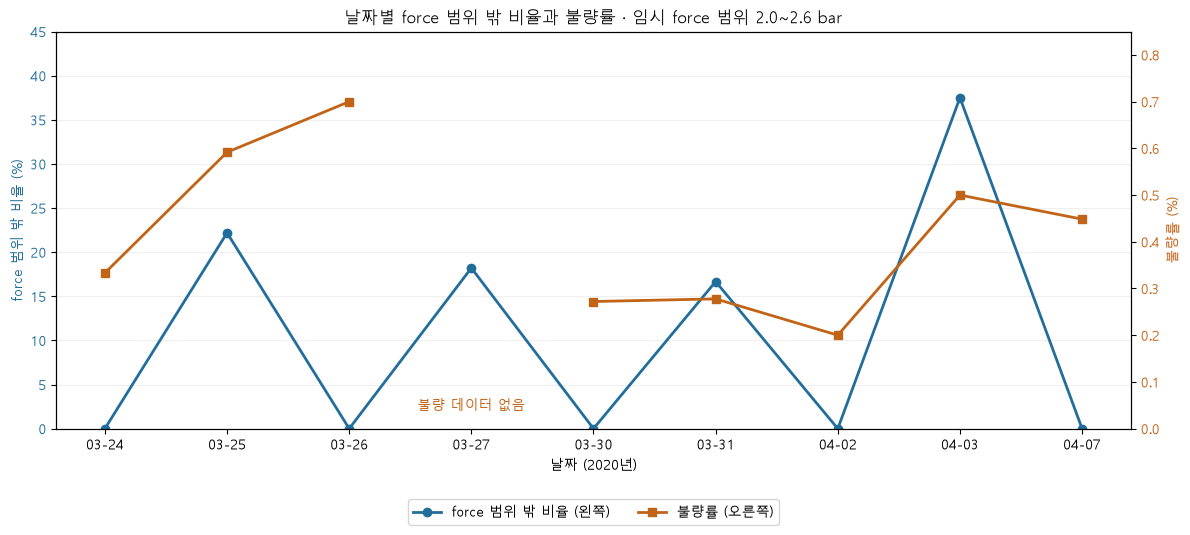

In [20]:
fig, ax1 = plt.subplots(figsize=(12,5.5))
ax2 = ax1.twinx()
x = np.arange(len(daily))
line1 = ax1.plot(x, daily['force 범위 밖 비율(%)'], color='#216E9A', marker='o', linewidth=2, label='force 범위 밖 비율 (왼쪽)')
line2 = ax2.plot(x, daily['해당 날짜 불량률(%)'], color='#C16418', marker='s', linewidth=2, label='불량률 (오른쪽)')
ax1.set_xticks(x, daily['날짜'].dt.strftime('%m-%d'))
ax1.set_xlabel('날짜 (2020년)')
ax1.set_ylabel('force 범위 밖 비율 (%)', color='#216E9A')
ax2.set_ylabel('불량률 (%)', color='#C16418')
ax1.tick_params(axis='y', labelcolor='#216E9A')
ax2.tick_params(axis='y', labelcolor='#C16418')
ax1.set_ylim(0,45)
ax2.set_ylim(0,0.85)
ax1.grid(axis='y', alpha=.2)
for i in np.flatnonzero(daily['해당 날짜 불량률(%)'].isna()):
    ax2.annotate('불량 데이터 없음', (i, .04), xytext=(0,0), textcoords='offset points', ha='center', color='#C16418', fontsize=10)
lines = line1 + line2
ax1.legend(lines, [l.get_label() for l in lines], loc='upper center', bbox_to_anchor=(.5,-.16), ncol=2)
ax1.set_title('날짜별 force 범위 밖 비율과 불량률 · 임시 force 범위 2.0~2.6 bar')
fig.tight_layout()
fig.savefig(OUT/'force_defect_dual_axis.png', dpi=160, bbox_inches='tight')
plt.show()
plt.close(fig)

## 4. Pearson 상관계수
날짜당 한 관측으로 계산하며 가중치는 사용하지 않습니다. 두 비율이 모두 있는 날짜만 사용합니다. 작은 표본의 상관계수이며 인과관계를 의미하지 않습니다.

In [21]:
valid = daily.dropna(subset=['force 범위 밖 비율(%)','해당 날짜 불량률(%)'])
r = valid['force 범위 밖 비율(%)'].corr(valid['해당 날짜 불량률(%)'], method='pearson')
# 중심화 내적으로 독립 재계산해 pandas 결과와 대조.
u = valid['force 범위 밖 비율(%)'].to_numpy()
v = valid['해당 날짜 불량률(%)'].to_numpy()
u, v = u-u.mean(), v-v.mean()
check_r = np.dot(u,v) / np.sqrt(np.dot(u,u)*np.dot(v,v))
assert np.isclose(r,check_r)
correlation = pd.DataFrame({'Pearson r':[r], '유효 날짜 수':[len(valid)], '제외 날짜 수':[len(daily)-len(valid)]})
display(correlation.round(6))
print('제외 날짜:', daily.loc[daily['해당 날짜 불량률(%)'].isna(),'날짜'].dt.strftime('%Y-%m-%d').tolist())
assert hashlib.sha256(BOOK.read_bytes()).hexdigest() == source_hash
correlation.to_csv(OUT/'pearson.csv', index=False, encoding='utf-8-sig')
(OUT/'metadata.json').write_text(json.dumps({'source_sha256':source_hash,'pearson_r':r,'n_dates':len(valid),'defects_definition':'sum(result.defect) by date, per user request','denominator':'Raw data row count by date','missing_result':'NaN'},ensure_ascii=False,indent=2),encoding='utf-8')

,Pearson r,유효 날짜 수,제외 날짜 수
0,0.272799,8,1


제외 날짜: ['2020-03-27']


286

## 이후 분석 추가 위치
다음 요청부터 이 아래에 새 셀을 추가합니다. 별도 분석 노트북은 만들지 않습니다. 표는 display 후 CSV, 그래프는 화면 출력과 PNG 저장을 함께 수행합니다.

In [22]:
print('통합 분석 완료. 다음 분석은 이 아래에 이어서 작성합니다.')

통합 분석 완료. 다음 분석은 이 아래에 이어서 작성합니다.


## 4부 · 2020-03-26의 전류·전압·용접시간 비교

원본의 모든 행을 유지한다. 자료 1~3을 통해 확인되는 분포 차이와 날짜별 위치를 비교하며, 불량 원인을 단정하지 않는다. 이 절은 독립 실행 가능하다.

In [23]:
from pathlib import Path
import os, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

m26_base = globals().get('BASE', Path('C:/Users/sj789/OneDrive/바탕 화면/KAMP 데이터분석'))
m26_out = Path(os.environ.get('KAMP_M26_OUTPUT', str(m26_base / 'results')))
m26_out.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({'font.family': 'Malgun Gothic', 'axes.unicode_minus': False, 'font.size': 11})
m26_source = m26_base / 'data/Welding Data Set_01.xlsx'
m26_hash = hashlib.sha256(m26_source.read_bytes()).hexdigest()
m26_raw = pd.read_excel(m26_source, sheet_name='Raw data')
m26_result = pd.read_excel(m26_source, sheet_name='result')
m26_cols = ['weld current(kA)', 'weld Voltage(v)', 'weld time(ms)']
m26_labels = ['전류 (kA)', '전압 (V)', '용접시간 (ms)']
for frame in (m26_raw, m26_result):
    frame['날짜'] = pd.to_datetime(frame['working time'], errors='raise').dt.normalize()
    assert frame['날짜'].notna().all()
for col in m26_cols + ['weld force(bar)']:
    m26_raw[col] = pd.to_numeric(m26_raw[col], errors='raise')
    assert np.isfinite(m26_raw[col]).all(), f'{col}: 결측 또는 무한대 확인 필요'
m26_result['defect'] = pd.to_numeric(m26_result['defect'], errors='raise')
assert m26_result['defect'].notna().all() and m26_result['defect'].ge(0).all()
assert not m26_result.duplicated(['날짜', 'Machine_Name', 'Item No', 'defect type']).any()
m26_target = pd.Timestamp('2020-03-26')
m26_mask = m26_raw['날짜'].eq(m26_target)
assert m26_mask.any() and (~m26_mask).any()
m26_groups = {'3/26': m26_raw.loc[m26_mask], '나머지 날짜': m26_raw.loc[~m26_mask]}
for d in set(m26_raw['날짜']) & set(m26_result['날짜']):
    entities = ['Machine_Name', 'Item No']
    assert set(map(tuple, m26_raw.loc[m26_raw['날짜'].eq(d), entities].values)) == set(map(tuple, m26_result.loc[m26_result['날짜'].eq(d), entities].values))
print(f'분석 대상: 전체 {len(m26_raw):,}행, {m26_raw["날짜"].nunique()}일 / 3/26 {m26_mask.sum():,}행 / 나머지 {(~m26_mask).sum():,}행')
print('세 변수 및 날짜 결측 없음. 이상치 제거·보간·중복 제거 없이 원본 행을 사용.')
print('비교군은 3/26을 제외한 모든 행을 합침. 생산 데이터가 많은 날짜에 더 큰 가중치가 부여됨.')



분석 대상: 전체 11,939행, 9일 / 3/26 1,000행 / 나머지 10,939행
세 변수 및 날짜 결측 없음. 이상치 제거·보간·중복 제거 없이 원본 행을 사용.
비교군은 3/26을 제외한 모든 행을 합침. 생산 데이터가 많은 날짜에 더 큰 가중치가 부여됨.


### 자료 1 · 기술통계 비교

3/26과 그 외 8일의 전체 행을 비교한다. 표본 수·평균·중앙값·표본 표준편차·Q1·Q3을 제시한다.

,변수,그룹,N,평균,중앙값,표준편차,Q1,Q3
0,전류 (kA),3/26,1000,14.648110,14.620,0.075160,14.58000,14.730
1,전류 (kA),나머지 날짜,10939,14.716976,14.730,0.098914,14.64000,14.760
2,전압 (V),3/26,1000,2.702032,2.701,0.004075,2.69975,2.704
3,전압 (V),나머지 날짜,10939,2.704424,2.702,0.025765,2.69900,2.706
4,용접시간 (ms),3/26,1000,71.749600,72.000,0.621947,71.00000,72.000
5,용접시간 (ms),나머지 날짜,10939,71.721794,72.000,0.632942,71.00000,72.000


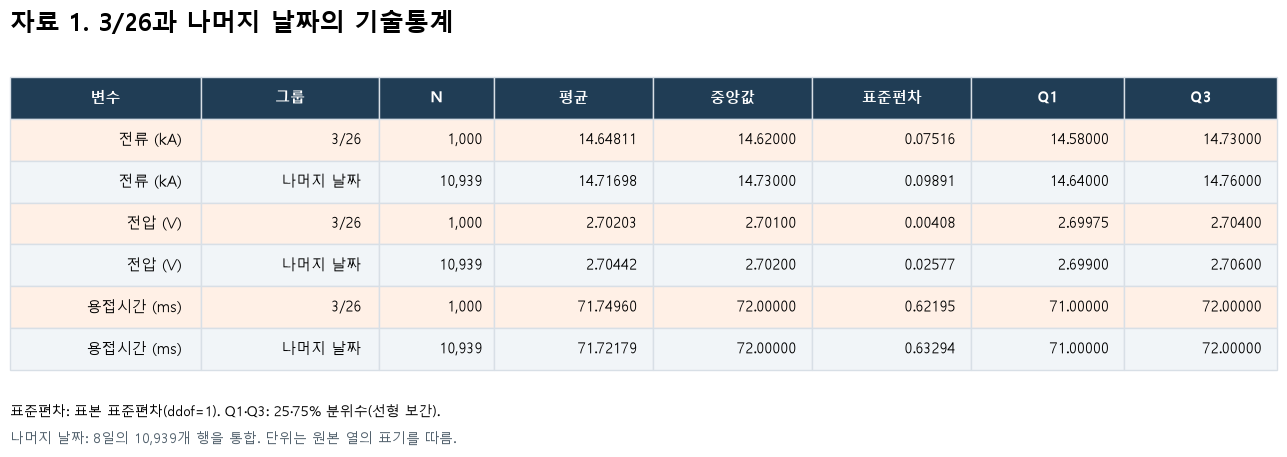

In [24]:
m26_stats_rows = []
for col, label in zip(m26_cols, m26_labels):
    for group, frame in m26_groups.items():
        s = frame[col]
        m26_stats_rows.append({'변수': label, '그룹': group, 'N': len(s), '평균': s.mean(), '중앙값': s.median(), '표준편차': s.std(ddof=1), 'Q1': s.quantile(.25), 'Q3': s.quantile(.75)})
m26_stats = pd.DataFrame(m26_stats_rows)
display(m26_stats.round(6))
m26_stats.to_csv(m26_out/'m26_01_descriptive_statistics.csv', index=False, encoding='utf-8-sig')
fig, ax = plt.subplots(figsize=(13, 4.7))
ax.axis('off')
ax.set_title('자료 1. 3/26과 나머지 날짜의 기술통계', loc='left', fontsize=18, fontweight='bold', pad=22)
cells = [[r['변수'], r['그룹'], f'{r["N"]:,}'] + [f'{r[k]:.5f}' for k in ['평균','중앙값','표준편차','Q1','Q3']] for _, r in m26_stats.iterrows()]
tbl = ax.table(cellText=cells, colLabels=m26_stats.columns, cellLoc='right', colWidths=[.15,.14,.09,.125,.125,.125,.12,.12], bbox=[0,.20,1,.76])
tbl.auto_set_font_size(False)
tbl.set_fontsize(10.5)
for (r,c), cell in tbl.get_celld().items():
    cell.set_edgecolor('#D8DFE6')
    if r == 0:
        cell.set_facecolor('#203D55'); cell.set_text_props(color='white', weight='bold')
    else:
        cell.set_facecolor('#FFF0E6' if r % 2 else '#F1F5F8')
ax.text(0,.08,'표준편차: 표본 표준편차(ddof=1). Q1·Q3: 25·75% 분위수(선형 보간).',transform=ax.transAxes,fontsize=10)
ax.text(0,.01,'나머지 날짜: 8일의 10,939개 행을 통합. 단위는 원본 열의 표기를 따름.',transform=ax.transAxes,fontsize=10,color='#52616D')
fig.tight_layout()
fig.savefig(m26_out/'m26_01_descriptive_statistics.png', dpi=180, bbox_inches='tight')
plt.show(); plt.close(fig)



### 자료 2 · 분포 비교

그룹 내 비율 히스토그램과 경험적 누적분포를 사용한다. 두 그룹에 동일한 구간 경계를 적용한다.

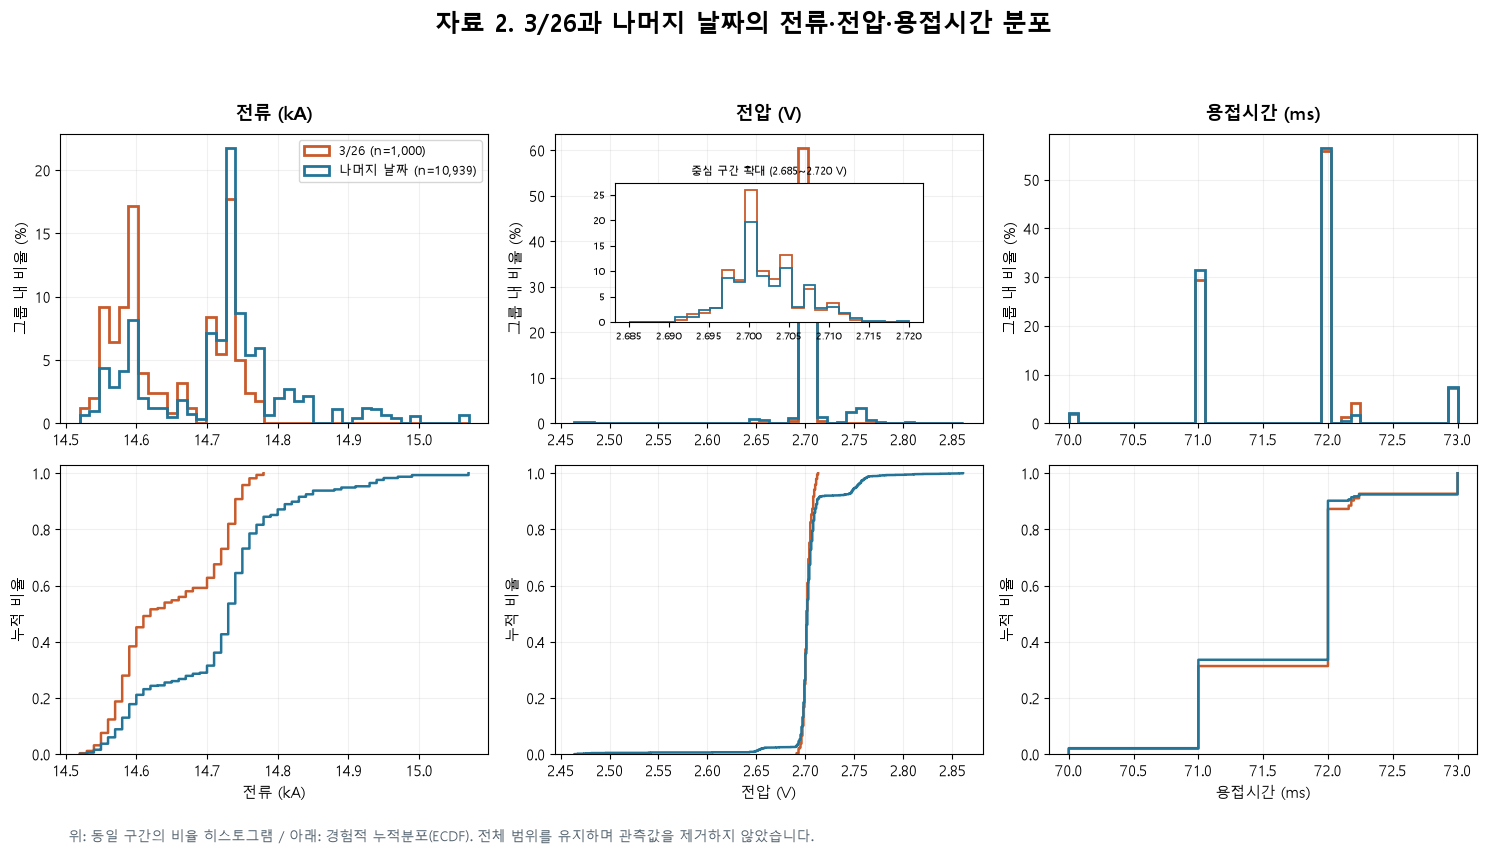

In [25]:
# 표본 수 차이를 보정한 비율 히스토그램과 전체 범위 ECDF를 함께 비교한다.
m26_colors = {'3/26': '#C85B2B', '나머지 날짜': '#247497'}
fig, axes = plt.subplots(2,3,figsize=(15,8.5))
for j,(col,label) in enumerate(zip(m26_cols,m26_labels)):
    all_values = m26_raw[col].to_numpy()
    bins = np.histogram_bin_edges(all_values, bins=40)
    for group,frame in m26_groups.items():
        values = frame[col].to_numpy()
        axes[0,j].hist(values,bins=bins,weights=np.ones(len(values))*100/len(values),histtype='step',linewidth=2,color=m26_colors[group],label=f'{group} (n={len(values):,})')
        x = np.sort(values)
        axes[1,j].step(x,np.arange(1,len(x)+1)/len(x),where='post',color=m26_colors[group],linewidth=1.8,label=group)
    axes[0,j].set_title(label,weight='bold',pad=10)
    axes[0,j].set_ylabel('그룹 내 비율 (%)')
    axes[1,j].set_ylabel('누적 비율')
    axes[1,j].set_xlabel(label)
    axes[1,j].set_ylim(0,1.03)
    for i in range(2): axes[i,j].grid(alpha=.18)
axes[0,0].legend(fontsize=9)
# 전압의 주된 분포가 극단값에 가려지므로 확대 보조 그림을 추가한다.
inset=axes[0,1].inset_axes([.14,.35,.72,.48])
vbins=np.linspace(2.685,2.72,25)
for group,frame in m26_groups.items():
    v=frame[m26_cols[1]].to_numpy()
    inset.hist(v,bins=vbins,weights=np.ones(len(v))*100/len(v),histtype='step',linewidth=1.3,color=m26_colors[group])
inset.set_title('중심 구간 확대 (2.685~2.720 V)',fontsize=8)
inset.tick_params(labelsize=7)
fig.suptitle('자료 2. 3/26과 나머지 날짜의 전류·전압·용접시간 분포',fontsize=18,weight='bold',y=.99)
fig.text(.05,.012,'위: 동일 구간의 비율 히스토그램 / 아래: 경험적 누적분포(ECDF). 전체 범위를 유지하며 관측값을 제거하지 않았습니다.',fontsize=10,color='#52616D')
fig.tight_layout(rect=[0,.04,1,.95])
fig.savefig(m26_out/'m26_02_distributions.png',dpi=180,bbox_inches='tight')
plt.show(); plt.close(fig)



### 자료 3 · 날짜별 대표값과 불량률

평균·중앙값·Q1~Q3과 불량률을 같은 날짜 축에 별도 패널로 표시한다. 불량 정보가 없는 날짜는 NaN으로 남긴다.

,생산 데이터 수,전류 (kA) 평균,전류 (kA) 중앙값,전류 (kA) Q1,전류 (kA) Q3,전압 (V) 평균,전압 (V) 중앙값,전압 (V) Q1,전압 (V) Q3,용접시간 (ms) 평균,용접시간 (ms) 중앙값,용접시간 (ms) Q1,용접시간 (ms) Q3,불량 개수,불량률 (%),force 주요 구간 밖 비율 (%)
날짜,,,,,,,,,,,,,,,,
2020-03-24,1200,14.685817,14.720,14.60,14.75,2.702092,2.702,2.69900,2.705,71.728583,72.0,71.0,72.0,4.0,0.333333,0.000000
2020-03-25,1352,14.748203,14.740,14.71,14.81,2.706868,2.702,2.69900,2.709,71.719896,72.0,71.0,72.0,8.0,0.591716,22.189349
2020-03-26,1000,14.648110,14.620,14.58,14.73,2.702032,2.701,2.69975,2.704,71.749600,72.0,71.0,72.0,7.0,0.700000,0.000000
2020-03-27,1648,14.754266,14.750,14.73,14.79,2.706118,2.703,2.69900,2.708,71.714988,72.0,71.0,72.0,NaN,NaN,18.203883
2020-03-30,1470,14.664592,14.700,14.59,14.73,2.701830,2.701,2.70000,2.704,71.738503,72.0,71.0,72.0,4.0,0.272109,0.000000
2020-03-31,1800,14.746411,14.740,14.72,14.78,2.705717,2.702,2.69900,2.708,71.718500,72.0,71.0,72.0,5.0,0.277778,16.666667
2020-04-02,2000,14.694350,14.730,14.62,14.75,2.702198,2.702,2.69900,2.705,71.728300,72.0,71.0,72.0,4.0,0.200000,0.000000
2020-04-03,800,14.788625,14.785,14.73,14.85,2.709721,2.703,2.69900,2.745,71.720375,72.0,71.0,72.0,4.0,0.500000,37.500000
2020-04-07,669,14.635770,14.610,14.58,14.71,2.702034,2.701,2.70000,2.705,71.684604,72.0,71.0,72.0,3.0,0.448430,0.000000


,변수,3/26 평균,평균 오름차순 순위,전체 날짜 수,최저 평균 날짜,최고 평균 날짜
0,전류 (kA),14.648110,2,9,2020-04-07,2020-04-03
1,전압 (V),2.702032,2,9,2020-03-30,2020-04-03
2,용접시간 (ms),71.749600,9,9,2020-04-07,2020-03-26


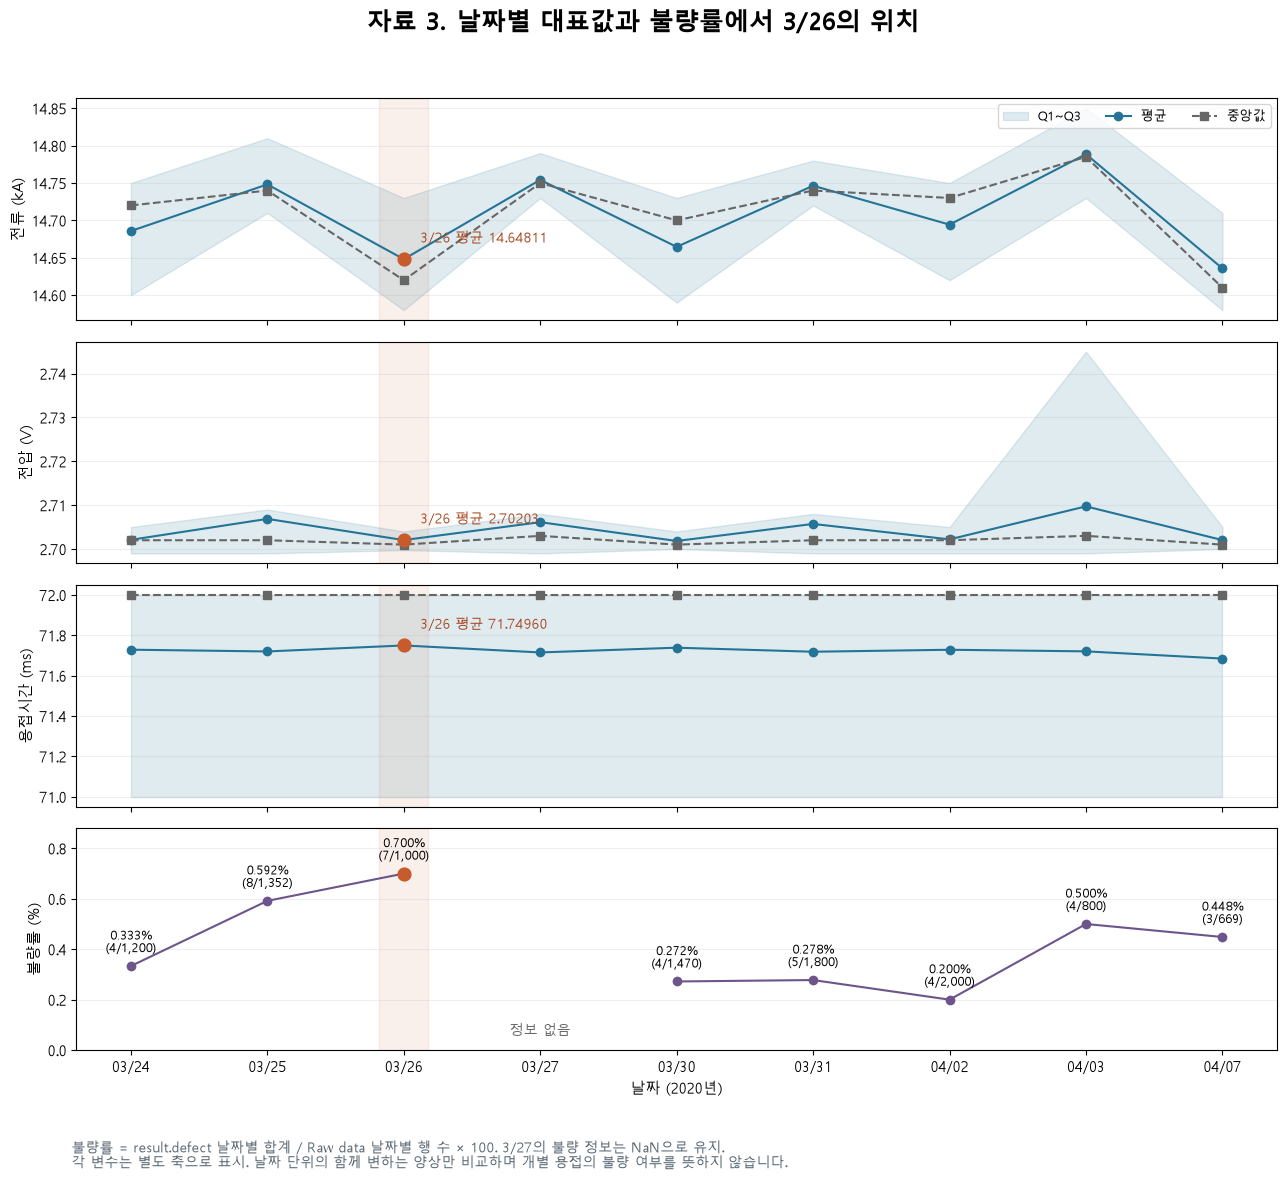

In [26]:
m26_daily = m26_raw.groupby('날짜').size().rename('생산 데이터 수').to_frame()
for col,label in zip(m26_cols,m26_labels):
    gb=m26_raw.groupby('날짜')[col]
    m26_daily[label+' 평균']=gb.mean()
    m26_daily[label+' 중앙값']=gb.median()
    m26_daily[label+' Q1']=gb.quantile(.25)
    m26_daily[label+' Q3']=gb.quantile(.75)
m26_defects=m26_result.groupby('날짜')['defect'].sum(min_count=1)
m26_daily['불량 개수']=m26_defects.reindex(m26_daily.index)
m26_daily['불량률 (%)']=m26_daily['불량 개수']/m26_daily['생산 데이터 수']*100
m26_daily['force 주요 구간 밖 비율 (%)']=m26_raw.assign(outside=~m26_raw['weld force(bar)'].between(2,2.6)).groupby('날짜')['outside'].mean()*100
assert m26_daily['생산 데이터 수'].sum()==len(m26_raw)
assert m26_daily.loc[~m26_daily.index.isin(m26_defects.index),'불량률 (%)'].isna().all()
assert np.isclose(m26_daily.loc[m26_target,'불량률 (%)'],7/1000*100)
display(m26_daily.round(6))
m26_daily.to_csv(m26_out/'m26_03_daily_features_defects.csv',encoding='utf-8-sig',na_rep='NaN')
m26_rankrows=[]
for label in m26_labels:
    key=label+' 평균'
    m26_rankrows.append({'변수':label,'3/26 평균':m26_daily.loc[m26_target,key],'평균 오름차순 순위':int(m26_daily[key].rank(method='min').loc[m26_target]),'전체 날짜 수':len(m26_daily),'최저 평균 날짜':m26_daily[key].idxmin().strftime('%Y-%m-%d'),'최고 평균 날짜':m26_daily[key].idxmax().strftime('%Y-%m-%d')})
m26_rank=pd.DataFrame(m26_rankrows)
display(m26_rank)
m26_rank.to_csv(m26_out/'m26_03_target_ranks.csv',index=False,encoding='utf-8-sig')
fig,axes=plt.subplots(4,1,figsize=(13,12),sharex=True)
x=np.arange(len(m26_daily)); ti=int(np.flatnonzero(m26_daily.index==m26_target)[0])
for j,label in enumerate(m26_labels):
    ax=axes[j]
    ax.fill_between(x,m26_daily[label+' Q1'],m26_daily[label+' Q3'],color='#247497',alpha=.14,label='Q1~Q3')
    ax.plot(x,m26_daily[label+' 평균'],marker='o',color='#247497',label='평균')
    ax.plot(x,m26_daily[label+' 중앙값'],marker='s',linestyle='--',color='#666666',label='중앙값')
    ax.scatter([ti],[m26_daily.loc[m26_target,label+' 평균']],s=85,color='#C85B2B',zorder=5)
    val=m26_daily.loc[m26_target,label+' 평균']
    ax.annotate(f'3/26 평균 {val:.5f}',(ti,val),xytext=(12,12),textcoords='offset points',color='#A44219',fontsize=10)
    ax.set_ylabel(label)
    ax.grid(axis='y',alpha=.2)
axes[0].legend(loc='upper right',ncol=3,fontsize=9)
axes[3].plot(x,m26_daily['불량률 (%)'],marker='o',color='#6D558B')
axes[3].scatter([ti],[m26_daily.loc[m26_target,'불량률 (%)']],s=85,color='#C85B2B',zorder=5)
for i,(_,r) in enumerate(m26_daily.iterrows()):
    if pd.isna(r['불량률 (%)']):
        axes[3].text(i,.06,'정보 없음',ha='center',fontsize=10,color='#666666')
    else:
        axes[3].annotate(f'{r["불량률 (%)"]:.3f}%\n({int(r["불량 개수"]):,}/{int(r["생산 데이터 수"]):,})',(i,r['불량률 (%)']),xytext=(0,10),textcoords='offset points',ha='center',fontsize=9)
axes[3].set(ylim=(0,.88),ylabel='불량률 (%)',xlabel='날짜 (2020년)')
axes[3].grid(axis='y',alpha=.2)
axes[3].set_xticks(x,m26_daily.index.strftime('%m/%d'))
for ax in axes: ax.axvspan(ti-.18,ti+.18,color='#C85B2B',alpha=.09)
fig.suptitle('자료 3. 날짜별 대표값과 불량률에서 3/26의 위치',fontsize=18,weight='bold',y=.985)
fig.text(.06,.02,'불량률 = result.defect 날짜별 합계 / Raw data 날짜별 행 수 × 100. 3/27의 불량 정보는 NaN으로 유지.\n각 변수는 별도 축으로 표시. 날짜 단위의 함께 변하는 양상만 비교하며 개별 용접의 불량 여부를 뜻하지 않습니다.',fontsize=10,color='#52616D')
fig.tight_layout(rect=[0,.065,1,.96])
fig.savefig(m26_out/'m26_03_daily_features_defects.png',dpi=180,bbox_inches='tight')
plt.show(); plt.close(fig)



### 확인된 차이와 해석

force는 주요 구간에서의 보조 비교에만 사용한다.

In [27]:
# force는 보조 점검에만 사용: 주요 force 구간으로 한정해 비교군 구성의 영향을 확인.
m26_main=m26_raw.loc[m26_raw['weld force(bar)'].between(2,2.6)]
m26_sensitivity=[]
for col,label in zip(m26_cols,m26_labels):
    for group,mask in [('3/26',m26_main['날짜'].eq(m26_target)),('나머지 날짜',~m26_main['날짜'].eq(m26_target))]:
        s=m26_main.loc[mask,col]
        m26_sensitivity.append({'변수':label,'그룹':group,'주요 force 구간 N':len(s),'평균':s.mean(),'중앙값':s.median(),'표준편차':s.std(ddof=1)})
m26_sensitivity=pd.DataFrame(m26_sensitivity)
display(m26_sensitivity.round(6))
m26_sensitivity.to_csv(m26_out/'m26_aux_force_sensitivity.csv',index=False,encoding='utf-8-sig')
m26_a=m26_groups['3/26']; m26_b=m26_groups['나머지 날짜']
m26_lines=['# 2020-03-26 용접 데이터 분석 요약','',f'원본: Welding Data Set_01.xlsx의 Raw data와 result. 원본 SHA-256: {m26_hash}',
f'전체 {len(m26_raw):,}행, 9일. 3/26 {len(m26_a):,}행과 나머지 8일 {len(m26_b):,}행을 비교했다. 수치·날짜 결측은 없으며 관측값을 제거하지 않았다.','',
'## 확인된 차이','']
for col,label in zip(m26_cols,m26_labels):
    a,b=m26_a[col],m26_b[col]
    m26_lines.append(f'- {label}: 평균 {a.mean():.5f} vs {b.mean():.5f}, 차이 {a.mean()-b.mean():+.5f} ({(a.mean()/b.mean()-1)*100:+.3f}%). 중앙값 {a.median():.5f} vs {b.median():.5f}. 표준편차 {a.std():.5f} vs {b.std():.5f}.')
m26_low=m26_daily.loc[pd.Timestamp('2020-04-07')]
m26_lines += ['',
'- 전류: 3/26 평균은 9일 중 두 번째로 낮다. 다만 4/7은 평균 전류가 더 낮고 불량률은 약 0.448%로 3/26의 0.700%보다 낮다. 낮은 전류만으로 3/26의 높은 불량률을 설명할 수 없다.',
'- 전압: 3/26의 평균은 전체 날짜 중 두 번째로 낮지만, 4/7과 거의 같고 여러 날짜의 중심 구간과 겹친다. 순위만으로 큰 차이라고 판단하면 안 된다. 나머지 날짜를 통합했을 때의 큰 표준편차는 별도 분포 집단의 영향을 받는다.',
'- 용접시간: 3/26 평균은 9일 중 가장 높지만 모든 날짜의 중앙값은 72ms다. 평균 차이는 작고 분포가 크게 겹친다. 통계적 유의성이나 공학적 중요성을 확인한 결과는 아니다.',
'- 불량률: 정보가 있는 8일 중 3/26이 가장 높다(7/1,000 = 0.700%). 3/27은 정보가 없어 비교에서 제외하며 0으로 채우지 않았다.',
'','## force 보조 점검','주요 force 구간(2.0~2.6 bar, 양 끝 포함)으로 제한한 결과:','']
for label in m26_labels:
    s=m26_sensitivity.loc[m26_sensitivity['변수'].eq(label)].set_index('그룹')
    m26_lines.append(f'- {label}: 3/26 평균 {s.loc["3/26","평균"]:.5f}, 나머지 평균 {s.loc["나머지 날짜","평균"]:.5f}; 표준편차 {s.loc["3/26","표준편차"]:.5f} vs {s.loc["나머지 날짜","표준편차"]:.5f}.')
m26_lines += ['',
'전압의 산포 차이가 이 보조 비교에서 얼마나 줄어드는지 함께 봐야 한다. 이 구간은 품질 정상 기준이 아니며 인과관계를 통제한 분석도 아니다.',
'','## 해석 범위',
'이 자료에서 우선 확인되는 특징은 3/26의 낮은 전류 중심값이다. 전압 중심값과 용접시간은 비교군과 크게 겹친다. 다만 이 결과만으로 불량 원인을 특정할 수 없다.',
'불량률은 기존 사용자 지정식(result.defect 합계 / Raw data 행 수)을 유지했다. 불량유형 사이의 개체 중복 여부와 실제 생산량 정의가 별도로 확인되지 않았으므로 해석에 이 정의가 전제된다.',
'Raw data와 result는 날짜·설비·품목 범위로 집계했으며 개별 행에 불량 라벨을 붙이지 않았다. 행 수가 많아도 품질 비교의 유효 날짜는 8일이다. 시계열 의존성과 날짜별 조건 혼합이 있어 행을 독립 표본으로 간주한 유의성 검정은 수행하지 않았다.',
'나머지 날짜 통합 통계는 행 수 가중 비교이며, 날짜별 그래프는 각 날짜를 별도로 보여준다. 원본에 없는 품질 판정 기준이나 허용오차를 추정하지 않았다.']
m26_summary='\n'.join(m26_lines)+'\n'
(m26_out/'m26_summary.md').write_text(m26_summary,encoding='utf-8')
display(Markdown(m26_summary))
assert hashlib.sha256(m26_source.read_bytes()).hexdigest()==m26_hash
print('원본 파일 변경 없음. 자료 1~3 및 보조 표 저장 완료.')


,변수,그룹,주요 force 구간 N,평균,중앙값,표준편차
0,전류 (kA),3/26,1000,14.648110,14.620,0.075160
1,전류 (kA),나머지 날짜,9739,14.701366,14.730,0.088204
2,전압 (V),3/26,1000,2.702032,2.701,0.004075
3,전압 (V),나머지 날짜,9739,2.701882,2.702,0.008983
4,용접시간 (ms),3/26,1000,71.749600,72.000,0.621947
5,용접시간 (ms),나머지 날짜,9739,71.723247,72.000,0.633709


# 2020-03-26 용접 데이터 분석 요약

원본: Welding Data Set_01.xlsx의 Raw data와 result. 원본 SHA-256: d514d6aaa121630c04d7d51c97a56025e78e2c86868813f7722ba5db922c1f33
전체 11,939행, 9일. 3/26 1,000행과 나머지 8일 10,939행을 비교했다. 수치·날짜 결측은 없으며 관측값을 제거하지 않았다.

## 확인된 차이

- 전류 (kA): 평균 14.64811 vs 14.71698, 차이 -0.06887 (-0.468%). 중앙값 14.62000 vs 14.73000. 표준편차 0.07516 vs 0.09891.
- 전압 (V): 평균 2.70203 vs 2.70442, 차이 -0.00239 (-0.088%). 중앙값 2.70100 vs 2.70200. 표준편차 0.00408 vs 0.02577.
- 용접시간 (ms): 평균 71.74960 vs 71.72179, 차이 +0.02781 (+0.039%). 중앙값 72.00000 vs 72.00000. 표준편차 0.62195 vs 0.63294.

- 전류: 3/26 평균은 9일 중 두 번째로 낮다. 다만 4/7은 평균 전류가 더 낮고 불량률은 약 0.448%로 3/26의 0.700%보다 낮다. 낮은 전류만으로 3/26의 높은 불량률을 설명할 수 없다.
- 전압: 3/26의 평균은 전체 날짜 중 두 번째로 낮지만, 4/7과 거의 같고 여러 날짜의 중심 구간과 겹친다. 순위만으로 큰 차이라고 판단하면 안 된다. 나머지 날짜를 통합했을 때의 큰 표준편차는 별도 분포 집단의 영향을 받는다.
- 용접시간: 3/26 평균은 9일 중 가장 높지만 모든 날짜의 중앙값은 72ms다. 평균 차이는 작고 분포가 크게 겹친다. 통계적 유의성이나 공학적 중요성을 확인한 결과는 아니다.
- 불량률: 정보가 있는 8일 중 3/26이 가장 높다(7/1,000 = 0.700%). 3/27은 정보가 없어 비교에서 제외하며 0으로 채우지 않았다.

## force 보조 점검
주요 force 구간(2.0~2.6 bar, 양 끝 포함)으로 제한한 결과:

- 전류 (kA): 3/26 평균 14.64811, 나머지 평균 14.70137; 표준편차 0.07516 vs 0.08820.
- 전압 (V): 3/26 평균 2.70203, 나머지 평균 2.70188; 표준편차 0.00408 vs 0.00898.
- 용접시간 (ms): 3/26 평균 71.74960, 나머지 평균 71.72325; 표준편차 0.62195 vs 0.63371.

전압의 산포 차이가 이 보조 비교에서 얼마나 줄어드는지 함께 봐야 한다. 이 구간은 품질 정상 기준이 아니며 인과관계를 통제한 분석도 아니다.

## 해석 범위
이 자료에서 우선 확인되는 특징은 3/26의 낮은 전류 중심값이다. 전압 중심값과 용접시간은 비교군과 크게 겹친다. 다만 이 결과만으로 불량 원인을 특정할 수 없다.
불량률은 기존 사용자 지정식(result.defect 합계 / Raw data 행 수)을 유지했다. 불량유형 사이의 개체 중복 여부와 실제 생산량 정의가 별도로 확인되지 않았으므로 해석에 이 정의가 전제된다.
Raw data와 result는 날짜·설비·품목 범위로 집계했으며 개별 행에 불량 라벨을 붙이지 않았다. 행 수가 많아도 품질 비교의 유효 날짜는 8일이다. 시계열 의존성과 날짜별 조건 혼합이 있어 행을 독립 표본으로 간주한 유의성 검정은 수행하지 않았다.
나머지 날짜 통합 통계는 행 수 가중 비교이며, 날짜별 그래프는 각 날짜를 별도로 보여준다. 원본에 없는 품질 판정 기준이나 허용오차를 추정하지 않았다.


원본 파일 변경 없음. 자료 1~3 및 보조 표 저장 완료.
